### SVM Model for Customer Churn

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, classification_report, confusion_matrix, roc_curve
)

### Load ADASYN-Balanced Dataset

In [3]:
df = pd.read_csv('../mid-data/adasyn_balanced.csv')
target_col = 'Churn'

X = df.drop(columns=[target_col]).copy()
y = df[target_col].copy()

bool_cols = X.select_dtypes(include=['bool']).columns
if len(bool_cols) > 0:
    X[bool_cols] = X[bool_cols].astype(int)

print('Dataset shape:', df.shape)
print('Feature shape:', X.shape)
print('Target distribution:')
print(y.value_counts())

Dataset shape: (10410, 31)
Feature shape: (10410, 30)
Target distribution:
Churn
1    5236
0    5174
Name: count, dtype: int64


### Train-Test Split

In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print('Training samples:', X_train.shape[0])
print('Testing samples :', X_test.shape[0])

Training samples: 8328
Testing samples : 2082


### Pipeline

In [5]:
pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('svm', SVC(C=1, kernel='rbf', gamma='scale', probability=True, random_state=42))
])

best_model = pipeline.fit(X_train, y_train)

print('SVM Model Training Complete')
print(f'Training set score: {best_model.score(X_train, y_train):.4f}')
print(f'Test set score: {best_model.score(X_test, y_test):.4f}')

SVM Model Training Complete
Training set score: 0.8446
Test set score: 0.8199


### Model Evaluation

In [6]:
y_pred = best_model.predict(X_test)
y_prob = best_model.predict_proba(X_test)[:, 1]

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_prob)

print('SVM PERFORMANCE')
print(f'Accuracy  : {accuracy:.4f}')
print(f'Precision : {precision:.4f}')
print(f'Recall    : {recall:.4f}')
print(f'F1-score  : {f1:.4f}')
print(f'ROC-AUC   : {roc_auc:.4f}')
print('-' * 70)

cm = confusion_matrix(y_test, y_pred)
cm_df = pd.DataFrame(
    cm,
    index=['Actual No Churn (0)', 'Actual Churn (1)'],
    columns=['Predicted No Churn (0)', 'Predicted Churn (1)']
)

print('Confusion Matrix')
print(cm_df)
print('-' * 70)
print('Classification Report')
print(classification_report(y_test, y_pred))

SVM PERFORMANCE
Accuracy  : 0.8199
Precision : 0.8194
Recall    : 0.8233
F1-score  : 0.8213
ROC-AUC   : 0.9043
----------------------------------------------------------------------
Confusion Matrix
                     Predicted No Churn (0)  Predicted Churn (1)
Actual No Churn (0)                     845                  190
Actual Churn (1)                        185                  862
----------------------------------------------------------------------
Classification Report
              precision    recall  f1-score   support

           0       0.82      0.82      0.82      1035
           1       0.82      0.82      0.82      1047

    accuracy                           0.82      2082
   macro avg       0.82      0.82      0.82      2082
weighted avg       0.82      0.82      0.82      2082



### Confusion Matrix Plot

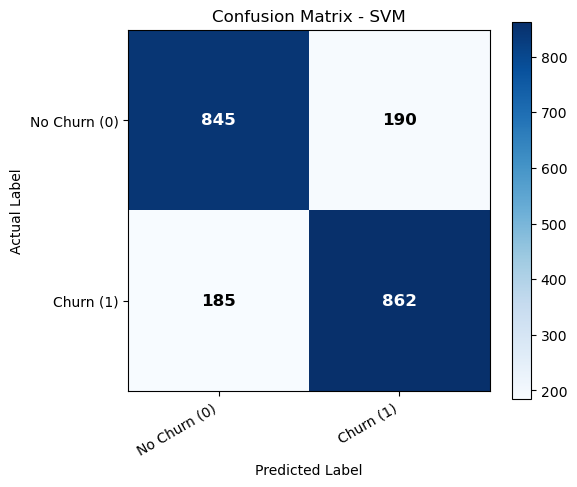

In [7]:
fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(cm, cmap=plt.cm.Blues)

classes = ['No Churn (0)', 'Churn (1)']
ax.set_title('Confusion Matrix - SVM')
ax.set_xlabel('Predicted Label')
ax.set_ylabel('Actual Label')

ax.set_xticks(np.arange(len(classes)))
ax.set_yticks(np.arange(len(classes)))
ax.set_xticklabels(classes)
ax.set_yticklabels(classes)

plt.setp(ax.get_xticklabels(), rotation=30, ha='right')

threshold = cm.max() / 2
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        ax.text(
            j, i, cm[i, j],
            ha='center',
            va='center',
            fontsize=12,
            fontweight='bold',
            color='white' if cm[i, j] > threshold else 'black'
        )

plt.colorbar(im, ax=ax)
plt.tight_layout()
plt.show()

### ROC Curve

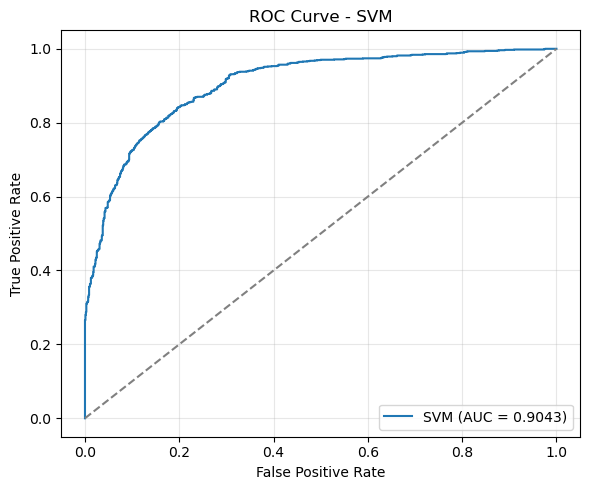

In [8]:
fpr, tpr, thresholds = roc_curve(y_test, y_prob)

plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, label=f'SVM (AUC = {roc_auc:.4f})')
plt.plot([0, 1], [0, 1], linestyle='--', color='gray')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - SVM')
plt.legend(loc='lower right')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

### Top Feature Importances (Permutation)

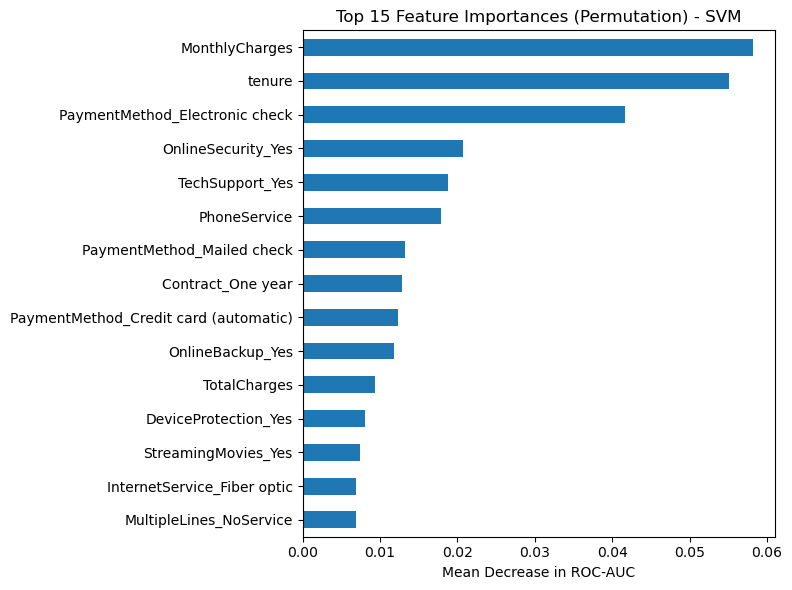

MonthlyCharges                           0.058170
tenure                                   0.055069
PaymentMethod_Electronic check           0.041589
OnlineSecurity_Yes                       0.020676
TechSupport_Yes                          0.018744
PhoneService                             0.017910
PaymentMethod_Mailed check               0.013204
Contract_One year                        0.012811
PaymentMethod_Credit card (automatic)    0.012339
OnlineBackup_Yes                         0.011860
TotalCharges                             0.009309
DeviceProtection_Yes                     0.008056
StreamingMovies_Yes                      0.007417
InternetService_Fiber optic              0.006943
MultipleLines_NoService                  0.006846
dtype: float64

In [9]:
from sklearn.inspection import permutation_importance

result = permutation_importance(
    best_model, X_test, y_test,
    n_repeats=10, random_state=42, scoring='roc_auc'
)

importances = pd.Series(result.importances_mean, index=X_test.columns)
top_features = importances.sort_values(ascending=False).head(15)

plt.figure(figsize=(8, 6))
top_features.sort_values().plot(kind='barh')
plt.title('Top 15 Feature Importances (Permutation) - SVM')
plt.xlabel('Mean Decrease in ROC-AUC')
plt.tight_layout()
plt.show()

top_features